# Notebook 03 — Feature Importance preliminar

Valida qué features aportan señal real al modelado antes de invertir
tiempo de tuning. Dos métodos complementarios:

1. **Mutual Information** (MI) — captura dependencia no-lineal y
   marginal univariada. Rápido.
2. **Permutation Importance** sobre XGB baseline — captura el impacto
   condicional (cuánto cae el AUC si se permuta esa feature, dejando
   las demás intactas). Más fiel a la importancia operativa.

**Foco**: validar si las features estructurales NUEVAS (RUP empresa,
competencia, post-conflicto, etc.) aparecen entre las top o no.

**Outputs**:
- `data/feature_importance.csv` (MI atraso + sobrecosto + permutation)
- `figuras/03_mi_top30.png`
- `figuras/03_permutation_top30.png`

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

RAIZ = Path('..').resolve()
sys.path.insert(0, str(RAIZ))
from src.preprocesamiento import preparar, RANDOM_STATE

DATA = RAIZ / 'data'
FIGS = RAIZ / 'figuras'
FIGS.mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

In [2]:
datos = preparar(DATA, aplicar_escalado=False)
print(f'Train: {datos.n_train} | Test: {datos.n_test} | Features: {len(datos.cols_features)}')
y_train_atraso = datos.y_train['tuvo_atraso']
y_train_sobrecosto = datos.y_train['tuvo_sobrecosto']

Train: 38664 | Test: 9667 | Features: 152


## 1. Mutual Information

In [3]:
from sklearn.feature_selection import mutual_info_classif

mi_atraso     = mutual_info_classif(datos.X_train.values, y_train_atraso,
                                     random_state=RANDOM_STATE, n_jobs=-1)
mi_sobrecosto = mutual_info_classif(datos.X_train.values, y_train_sobrecosto,
                                     random_state=RANDOM_STATE, n_jobs=-1)

mi_df = pd.DataFrame({
    'feature': datos.X_train.columns,
    'mi_atraso':     mi_atraso.round(5),
    'mi_sobrecosto': mi_sobrecosto.round(5),
})
mi_df['mi_promedio'] = ((mi_df['mi_atraso'] + mi_df['mi_sobrecosto']) / 2).round(5)
mi_df = mi_df.sort_values('mi_atraso', ascending=False).reset_index(drop=True)
print('Top 30 features por MI (atraso):')
mi_df.head(30)

Top 30 features por MI (atraso):


,feature,mi_atraso,mi_sobrecosto,mi_promedio
0,duracion_planificada_dias,0.21656,0.04717,0.13187
1,valor_del_contrato,0.08591,0.02696,0.05644
2,log_valor_contrato,0.08475,0.02662,0.05569
3,duracion_planificada_dias_was_nan,0.06890,0.02837,0.04864
4,localizaci_n_freq,0.03224,0.01953,0.02588
5,anios_empresa,0.02706,0.01511,0.02108
6,ciudad_freq,0.02509,0.01502,0.02006
7,pais_proveedor_CO,0.02491,0.00516,0.01504
8,rup_ingresos,0.02476,0.00965,0.01721
9,rup_utilidad_neta,0.02402,0.00983,0.01692


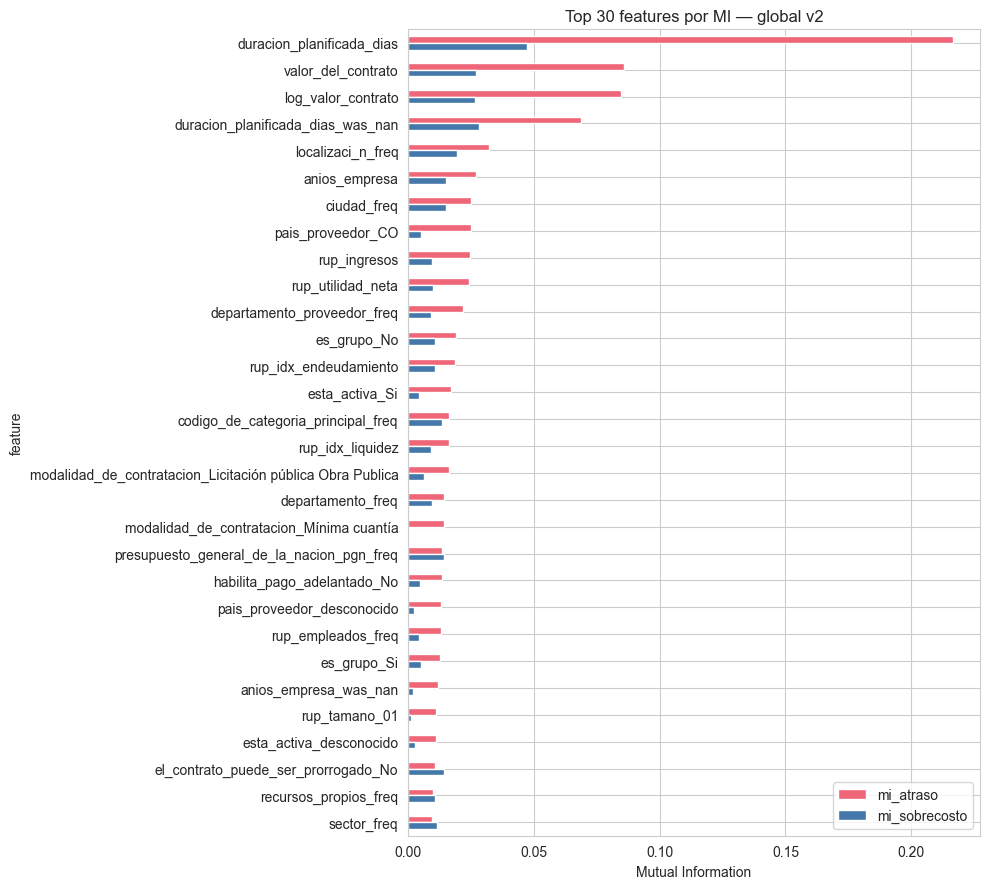

In [4]:
# Plot top 30 MI
top = mi_df.head(30).set_index('feature')[['mi_atraso','mi_sobrecosto']]
fig, ax = plt.subplots(figsize=(10, 9))
top.plot(kind='barh', ax=ax, color=['#ee6677','#4477aa'])
ax.invert_yaxis()
ax.set_xlabel('Mutual Information')
ax.set_title('Top 30 features por MI — global v2')
plt.tight_layout()
plt.savefig(FIGS / '03_mi_top30.png', dpi=120, bbox_inches='tight')
plt.show()

## 2. Permutation Importance con XGB baseline

In [5]:
from xgboost import XGBClassifier
from sklearn.inspection import permutation_importance

scale_pos = datos.scale_pos_weight['tuvo_atraso']

# Modelo baseline rápido
xgb = XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.1,
    tree_method='hist', n_jobs=-1, random_state=RANDOM_STATE,
    scale_pos_weight=scale_pos,
)
xgb.fit(datos.X_train, y_train_atraso)

# Permutation importance sobre subset del test (ahorra tiempo)
n_subset = min(2000, datos.n_test)
rng = np.random.default_rng(RANDOM_STATE)
idx_subset = rng.choice(datos.n_test, n_subset, replace=False)
X_sub = datos.X_test.iloc[idx_subset]
y_sub = datos.y_test['tuvo_atraso'].iloc[idx_subset]

print('Calculando Permutation Importance...')
perm = permutation_importance(xgb, X_sub, y_sub,
                              n_repeats=5, random_state=RANDOM_STATE,
                              scoring='roc_auc', n_jobs=-1)
perm_df = pd.DataFrame({
    'feature':           datos.X_train.columns,
    'perm_importance':   perm.importances_mean.round(5),
    'perm_std':          perm.importances_std.round(5),
}).sort_values('perm_importance', ascending=False).reset_index(drop=True)
print('Top 30 por Permutation Importance:')
perm_df.head(30)

Calculando Permutation Importance...


Top 30 por Permutation Importance:


,feature,perm_importance,perm_std
0,duracion_planificada_dias,0.23033,0.00574
1,duracion_planificada_dias_was_nan,0.12185,0.00462
2,valor_del_contrato,0.01162,0.00142
3,estado_bpin_No Válido,0.00878,0.00079
4,ciudad_freq,0.00712,0.00132
5,sector_freq,0.00584,0.00099
6,log_valor_contrato,0.00561,0.00025
7,localizaci_n_freq,0.00560,0.00097
8,departamento_freq,0.00478,0.00033
9,codigo_de_categoria_principal_freq,0.00457,0.00108


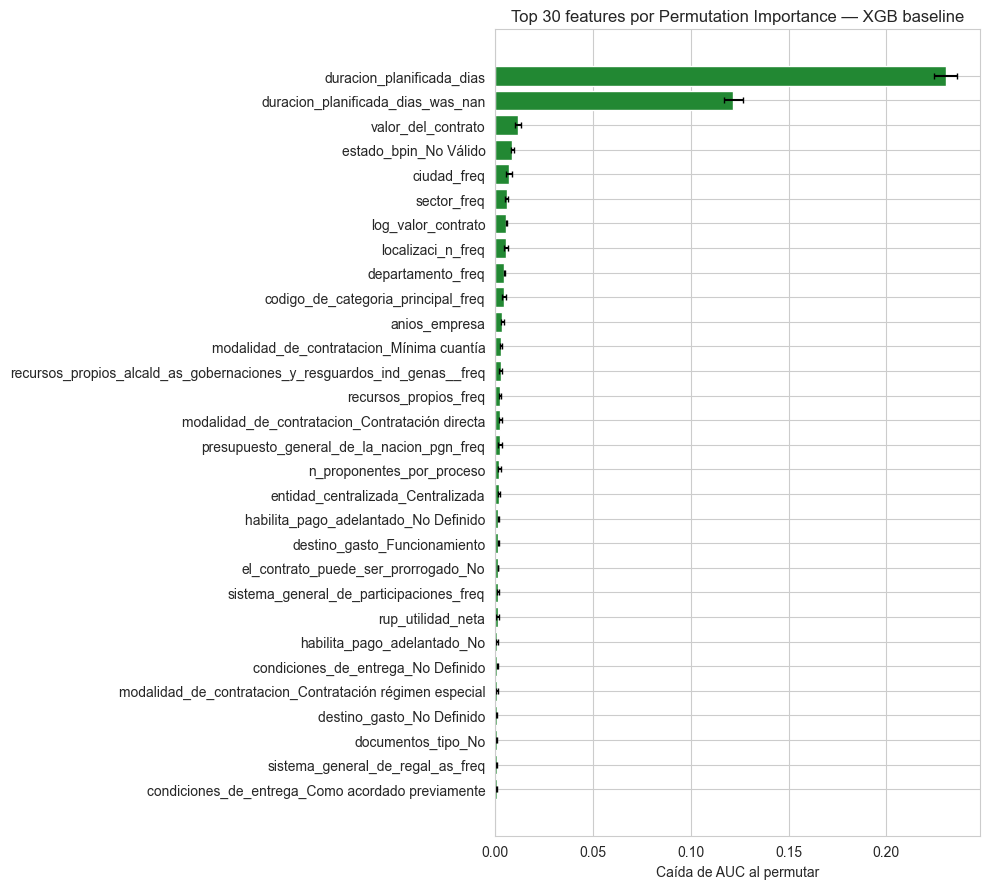

In [6]:
# Plot top 30 permutation
top_p = perm_df.head(30).set_index('feature')
fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(top_p.index, top_p['perm_importance'], xerr=top_p['perm_std'],
        color='#228833', capsize=2)
ax.invert_yaxis()
ax.set_xlabel('Caída de AUC al permutar')
ax.set_title('Top 30 features por Permutation Importance — XGB baseline')
plt.tight_layout()
plt.savefig(FIGS / '03_permutation_top30.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. ¿Las features estructurales nuevas aparecen en top?

Marca las features nuevas de v2 (no estaban en v1).

In [7]:
FEATURES_NUEVAS = [
    'rup_tamano', 'rup_empleados', 'rup_sanciones', 'rup_inhabilidad',
    'rup_activo_total', 'rup_patrimonio',
    'esta_activa', 'anios_empresa', 'pais_proveedor', 'departamento_proveedor',
    'n_proponentes_por_proceso',
    'log_valor_contrato', 'nacionalidad_representante_legal',
    'obligaciones_postconsumo', 'espostconflicto',
    'pilares_del_acuerdo', 'puntos_del_acuerdo',
    'codigo_de_categoria_principal', 'localizaci_n', 'tipodocproveedor',
]

def es_nueva(col):
    # OHE dummies prefijo el nombre original. Freq usa _freq sufijo.
    for f in FEATURES_NUEVAS:
        if col == f or col.startswith(f + '_') or col == f + '_freq':
            return True
    return False

mi_df['es_nueva']   = mi_df['feature'].apply(es_nueva)
perm_df['es_nueva'] = perm_df['feature'].apply(es_nueva)

# Posición de la primera NUEVA en cada ranking
primer_mi   = mi_df[mi_df['es_nueva']].iloc[0] if mi_df['es_nueva'].any() else None
primer_perm = perm_df[perm_df['es_nueva']].iloc[0] if perm_df['es_nueva'].any() else None

print('Primera feature NUEVA en ranking MI:')
print(primer_mi)
print()
print('Primera feature NUEVA en ranking Permutation:')
print(primer_perm)

Primera feature NUEVA en ranking MI:
feature          log_valor_contrato
mi_atraso                   0.08475
mi_sobrecosto               0.02662
mi_promedio                 0.05569
es_nueva                       True
Name: 2, dtype: object

Primera feature NUEVA en ranking Permutation:
feature            log_valor_contrato
perm_importance               0.00561
perm_std                      0.00025
es_nueva                         True
Name: 6, dtype: object


In [8]:
# Top features nuevas por permutation (las que valen la pena)
nuevas_perm = perm_df[perm_df['es_nueva']].head(15).copy()
nuevas_perm['rank_global'] = nuevas_perm.index
print('Top 15 features NUEVAS por Permutation Importance:')
nuevas_perm[['feature','perm_importance','perm_std','rank_global']]

Top 15 features NUEVAS por Permutation Importance:


,feature,perm_importance,perm_std,rank_global
6,log_valor_contrato,0.00561,0.00025,6
7,localizaci_n_freq,0.00560,0.00097,7
9,codigo_de_categoria_principal_freq,0.00457,0.00108,9
10,anios_empresa,0.00362,0.00078,10
16,n_proponentes_por_proceso,0.00221,0.00080,16
40,rup_activo_total_freq,0.00051,0.00040,40
45,nacionalidad_representante_legal_No definido,0.00036,0.00008,45
50,tipodocproveedor_NIT,0.00013,0.00010,50
52,rup_sanciones,0.00011,0.00002,52
53,tipodocproveedor_Otro,0.00011,0.00005,53


## 4. Consolidar + exportar

In [9]:
fi = mi_df.merge(perm_df[['feature','perm_importance','perm_std']],
                 on='feature', how='left')
fi.to_csv(DATA / 'feature_importance.csv', index=False, encoding='utf-8')
print(f'Exportado: feature_importance.csv ({fi.shape})')
fi.head(40)

Exportado: feature_importance.csv ((152, 7))


,feature,mi_atraso,mi_sobrecosto,mi_promedio,es_nueva,perm_importance,perm_std
0,duracion_planificada_dias,0.21656,0.04717,0.13187,False,0.23033,0.00574
1,valor_del_contrato,0.08591,0.02696,0.05644,False,0.01162,0.00142
2,log_valor_contrato,0.08475,0.02662,0.05569,True,0.00561,0.00025
3,duracion_planificada_dias_was_nan,0.06890,0.02837,0.04864,False,0.12185,0.00462
4,localizaci_n_freq,0.03224,0.01953,0.02588,True,0.00560,0.00097
5,anios_empresa,0.02706,0.01511,0.02108,True,0.00362,0.00078
6,ciudad_freq,0.02509,0.01502,0.02006,False,0.00712,0.00132
7,pais_proveedor_CO,0.02491,0.00516,0.01504,True,0.00000,0.00000
8,rup_ingresos,0.02476,0.00965,0.01721,False,0.00032,0.00023
9,rup_utilidad_neta,0.02402,0.00983,0.01692,False,0.00128,0.00071


In [10]:
# Resumen
resumen = {
    'n_features_total':          len(fi),
    'n_features_nuevas':         int(fi['es_nueva'].sum()),
    'top_feature_mi_atraso':     fi.iloc[0]['feature'] + f' (MI={fi.iloc[0]["mi_atraso"]:.4f})',
    'top_feature_perm':          perm_df.iloc[0]['feature'] + f' (Δ AUC={perm_df.iloc[0]["perm_importance"]:.4f})',
    'features_nuevas_top30_perm': int(perm_df.head(30)['es_nueva'].sum()),
    'features_nuevas_top10_perm': int(perm_df.head(10)['es_nueva'].sum()),
}
for k, v in resumen.items(): print(f'  {k:35s} {v}')

  n_features_total                    152
  n_features_nuevas                   70
  top_feature_mi_atraso               duracion_planificada_dias (MI=0.2166)
  top_feature_perm                    duracion_planificada_dias (Δ AUC=0.2303)
  features_nuevas_top30_perm          5
  features_nuevas_top10_perm          3
